In [3]:
import cv2
import numpy as np
import pywt

from pathlib import Path
from scipy.signal import wiener

print("Libraries loaded")

Libraries loaded


In [4]:
from pathlib import Path

ROOT = Path(
    r"C:\Users\leewa\Downloads\PCB-Defect-Inspection"
)


RAW_IMAGE_DIR = (
    ROOT
    /
    "data"
    /
    "raw"
    /
    "images"
)


SPLIT_DIR = (
    ROOT
    /
    "splits"
)


OUTPUT_DIR = (
    ROOT
    /
    "data"
    /
    "processed"
    /
    "leewanching"
)


print(ROOT)
print(SPLIT_DIR)
print(RAW_IMAGE_DIR)

C:\Users\leewa\Downloads\PCB-Defect-Inspection
C:\Users\leewa\Downloads\PCB-Defect-Inspection\splits
C:\Users\leewa\Downloads\PCB-Defect-Inspection\data\raw\images


In [5]:

def load_split(split_name):

    split_file = SPLIT_DIR / f"{split_name}.txt"

    with open(split_file, "r") as f:
        images = [
            x.strip()
            for x in f.readlines()
            if x.strip()
        ]

    return images


In [6]:

PARAMETERS = {

    "set1":{
        "gamma_low":0.90,
        "gamma_high":1.15,
        "cutoff":60,
        "c":1,
        "kernel_size":3,
        "wavelet":"db2",
        "detail_gain":1.45
    },

    "set2":{
        "gamma_low":0.80,
        "gamma_high":1.30,
        "cutoff":40,
        "c":1,
        "kernel_size":5,
        "wavelet":"haar",
        "detail_gain":1.70
    },

    "set3":{
        "gamma_low":0.95,
        "gamma_high":1.40,
        "cutoff":80,
        "c":1,
        "kernel_size":7,
        "wavelet":"db4",
        "detail_gain":2.00
    }
}

print(PARAMETERS.keys())


dict_keys(['set1', 'set2', 'set3'])


In [7]:

for set_name in PARAMETERS:

    for split in ["train","val","test"]:

        folder = OUTPUT_DIR / set_name / "images" / split

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

print("Output folders created")


Output folders created


In [8]:

def homomorphic_filter(image, gamma_low, gamma_high, cutoff, c):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = gray.astype(np.float32) + 1

    log_img = np.log(gray)

    fft = np.fft.fft2(log_img)
    fft_shift = np.fft.fftshift(fft)

    rows, cols = gray.shape

    crow = rows//2
    ccol = cols//2

    x, y = np.ogrid[:rows,:cols]

    distance = (x-crow)**2 + (y-ccol)**2

    high_pass = 1 - np.exp(
        -c * distance / (cutoff**2)
    )

    H = gamma_low + (gamma_high-gamma_low)*high_pass

    result = fft_shift * H

    inverse = np.fft.ifftshift(result)

    output = np.fft.ifft2(inverse)

    output = np.exp(np.real(output))

    output = cv2.normalize(
        output,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return output.astype(np.uint8)


In [9]:
def wiener_filter_image(image, kernel_size):

    image = image.astype(np.float32)


    image = image + 1e-6


    result = wiener(
        image,
        (kernel_size,kernel_size)
    )


    result = np.nan_to_num(
        result
    )


    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )


    return result.astype(np.uint8)

In [10]:

def dwt_detail_enhancement(image, wavelet, detail_gain):

    coeffs = pywt.dwt2(
        image,
        wavelet
    )

    LL,(LH,HL,HH) = coeffs

    LH *= detail_gain
    HL *= detail_gain
    HH *= detail_gain

    result = pywt.idwt2(
        (LL,(LH,HL,HH)),
        wavelet
    )

    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return result.astype(np.uint8)


In [11]:

def leewanching_pipeline(image, params):

    homo = homomorphic_filter(
        image,
        params["gamma_low"],
        params["gamma_high"],
        params["cutoff"],
        params["c"]
    )

    wiener_result = wiener_filter_image(
        homo,
        params["kernel_size"]
    )

    dwt_result = dwt_detail_enhancement(
        wiener_result,
        params["wavelet"],
        params["detail_gain"]
    )

    return dwt_result


Using image: C:\Users\leewa\Downloads\PCB-Defect-Inspection\data\raw\images\Spur\10_spur_01.jpg


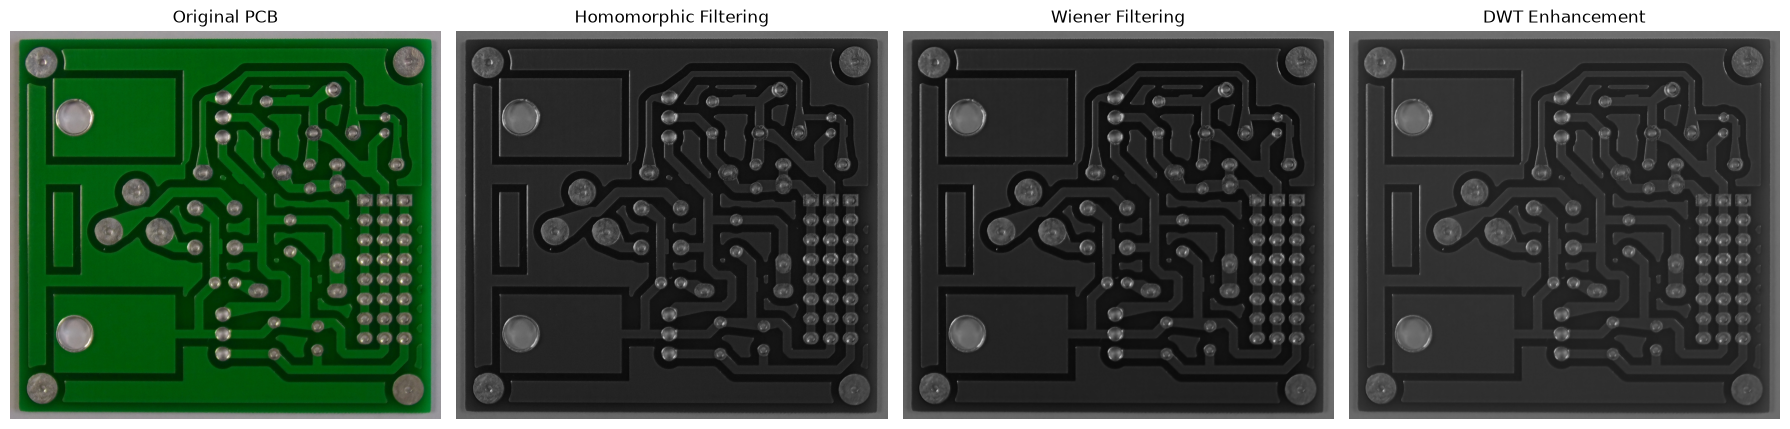

In [19]:
import matplotlib.pyplot as plt
import os
import cv2


# ======================================
# Load Spur Image
# ======================================

spur_folder = (
    r"C:\Users\leewa\Downloads\PCB-Defect-Inspection"
    r"\data\raw\images\Spur"
)

image_name = os.listdir(spur_folder)[90]

image_path = os.path.join(
    spur_folder,
    image_name
)

print("Using image:", image_path)


image = cv2.imread(image_path)


# ======================================
# Use YOUR Set 3 Parameters
# ======================================

set3_params = PARAMETERS["set3"]


# Stage 1
homo = homomorphic_filter(
    image,
    set3_params["gamma_low"],
    set3_params["gamma_high"],
    set3_params["cutoff"],
    set3_params["c"]
)


# Stage 2
wiener_result = wiener_filter_image(
    homo,
    set3_params["kernel_size"]
)


# Stage 3
dwt_result = dwt_detail_enhancement(
    wiener_result,
    set3_params["wavelet"],
    set3_params["detail_gain"]
)


# Convert original for display
original_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)



# ======================================
# Display
# ======================================

plt.figure(figsize=(18,5))


titles = [
    "Original PCB",
    "Homomorphic Filtering",
    "Wiener Filtering",
    "DWT Enhancement"
]


results = [
    original_rgb,
    homo,
    wiener_result,
    dwt_result
]


for i in range(4):

    plt.subplot(1,4,i+1)

    if i == 0:
        plt.imshow(results[i])
    else:
        plt.imshow(results[i], cmap="gray")

    plt.title(
        titles[i],
        fontsize=12
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

In [21]:

for split in ["train","val","test"]:

    print("Processing:", split)

    image_list = load_split(split)

    for filename in image_list:

        image_path = RAW_IMAGE_DIR / filename

        image = cv2.imread(str(image_path))

        if image is None:
            print("Cannot read:", filename)
            continue

        for set_name, params in PARAMETERS.items():

            processed = leewanching_pipeline(
                image,
                params
            )

            save_path = (
                OUTPUT_DIR
                /
                set_name
                /
                "images"
                /
                split
                /
                filename
            )

            save_path.parent.mkdir(
                parents=True,
                exist_ok=True
            )

            cv2.imwrite(
                str(save_path),
                processed
            )

print("========== PROCESSING COMPLETE ==========")


Processing: train
Processing: val
Processing: test
========== PROCESSING COMPLETE ==========
